# Section C – Machine Learning: Customer Churn Prediction


### Import & Data Engineering 

Preparing the data , so that it can be used in the machine learning model, will be making use of numerical numerical and categorical features such as:
["loyalty_score", "satisfaction_score", "complaint_flag", "customer_tenure", "avg_spend_per_txn", "account_type"]



In [1]:
#Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier #ML that I will be using.
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score ,precision_score ,recall_score ,classification_report,f1_score , confusion_matrix

In [2]:
df = pd.read_csv('C:/Users/SD 1/Downloads/Data Set Creation (1)/src/Lewis Churn Prediction Data')

In [3]:
df.head()

,Customer Id,Gender,Age,Region,Loyalty Score,Account Type,Join Date,Transaction Id,Store Id,Transaction Date,Category,Total Spent,Manager,Target,Satisfaction Score,Complaint Flag,Delivery Time Days,Customer Tenure(Years),Churn Flag
0,1,Male,60,Western Cape,23,Cash,2023-01-28,9,4,2025-10-06,Appliances,16198,Pamela Barnett,495090,6,0,1,2.824658,0
1,1,Male,60,Western Cape,23,Cash,2023-01-28,33,5,2025-05-15,Appliances,14341,Zachary Thomas,359297,6,0,1,2.824658,0
2,1,Male,60,Western Cape,23,Cash,2023-01-28,251,5,2025-10-15,Electronics,8682,Zachary Thomas,359297,6,0,1,2.824658,0
3,1,Male,60,Western Cape,23,Cash,2023-01-28,629,1,2025-02-01,Dining,15822,Melinda Gates,228106,6,0,1,2.824658,0
4,1,Male,60,Western Cape,23,Cash,2023-01-28,692,1,2025-01-25,Lounge,8813,Melinda Gates,228106,6,0,1,2.824658,0


In [4]:
df['avg_spend_per_txn'] = df.groupby('Customer Id')['Total Spent'].transform('sum') / \
                          df.groupby('Customer Id')['Transaction Id'].transform('count')
df.rename(columns = {'avg_spend_per_txn':'Average Revenue Per Customer'}, inplace = True)



In [5]:
df= df.drop(columns = ['Customer Id', 'Store Id','Join Date','Transaction Id','Transaction Date' , 'Target'], errors = 'ignore') #dropping columns thats not needed

In [6]:
df.head()

,Gender,Age,Region,Loyalty Score,Account Type,Category,Total Spent,Manager,Satisfaction Score,Complaint Flag,Delivery Time Days,Customer Tenure(Years),Churn Flag,Average Revenue Per Customer
0,Male,60,Western Cape,23,Cash,Appliances,16198,Pamela Barnett,6,0,1,2.824658,0,12771.2
1,Male,60,Western Cape,23,Cash,Appliances,14341,Zachary Thomas,6,0,1,2.824658,0,12771.2
2,Male,60,Western Cape,23,Cash,Electronics,8682,Zachary Thomas,6,0,1,2.824658,0,12771.2
3,Male,60,Western Cape,23,Cash,Dining,15822,Melinda Gates,6,0,1,2.824658,0,12771.2
4,Male,60,Western Cape,23,Cash,Lounge,8813,Melinda Gates,6,0,1,2.824658,0,12771.2


In [7]:
features = ['Loyalty Score', 'Satisfaction Score', 'Complaint Flag', 'Customer Tenure(Years)','Average Revenue Per Customer','Account Type','Manager' , 'Region']
X = df[features].copy()
y = df['Churn Flag'].copy()

### Clean and Pre-Process data 

In [8]:
df.isnull().sum()
df[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Loyalty Score                 800 non-null    int64  
 1   Satisfaction Score            800 non-null    int64  
 2   Complaint Flag                800 non-null    int64  
 3   Customer Tenure(Years)        800 non-null    float64
 4   Average Revenue Per Customer  800 non-null    float64
 5   Account Type                  800 non-null    object 
 6   Manager                       800 non-null    object 
 7   Region                        800 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 50.1+ KB


In [9]:
X = pd.get_dummies(X , columns = ['Account Type', 'Manager', 'Region'],drop_first = True)

###  Random Forest Classifier

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify = y)

In [11]:
rf = RandomForestClassifier(n_estimators = 100 , random_state =  42)
rf.fit(X_train , y_train)

RandomForestClassifier(random_state=42)

### Prediction 

In [12]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]  # note the correct method name


In [13]:
print('Accuracy:', accuracy_score(y_test ,y_pred))
print('Precision:' , precision_score(y_test ,y_pred))
print('Recall:',recall_score(y_test ,y_pred))
print('F1:' ,f1_score(y_test ,y_pred))

Accuracy: 0.955
Precision: 0.95
Recall: 0.9047619047619048
F1: 0.926829268292683


In [14]:
print(classification_report(y_test ,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       137
           1       0.95      0.90      0.93        63

    accuracy                           0.95       200
   macro avg       0.95      0.94      0.95       200
weighted avg       0.95      0.95      0.95       200



### Feature Importance

Feature: Average Revenue Per Customer , Score: 0.26230
Feature: Customer Tenure(Years) , Score: 0.22396
Feature: Loyalty Score , Score: 0.18416
Feature: Satisfaction Score , Score: 0.11422
Feature: Region_Gauteng , Score: 0.04395


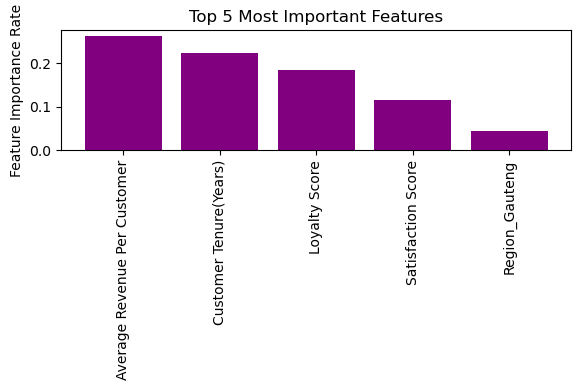

In [29]:
importance= rf.feature_importances_
sorted_idx =importance.argsort()[::-1][:5]  # Get indices of top 5 features
# Printing only the  top 5
for i in sorted_idx:
    print(f'Feature: {X.columns[i]} , Score: {importance[i]:.5f}')

# Plot only top 5
plt.figure(figsize=(6,4))
plt.bar(X.columns[sorted_idx], importance[sorted_idx], color='purple')
plt.xticks(rotation=90)
plt.ylabel('Feature Importance Rate')
plt.title("Top 5 Most Important Features")
plt.tight_layout()
plt.show()

### Confusion Matrix

Text(0.5, 1.0, "Random Forest Classifiers' Confusion Matrix")

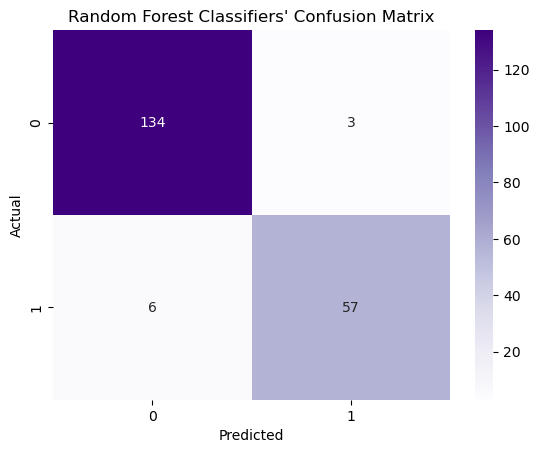

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot= True,
           fmt = 'd',cmap = 'Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Random Forest Classifiers' Confusion Matrix")

### Correct vs Incorrect predicted churn outcomes

Churn Flag
True     191
False      9
Name: count, dtype: int64


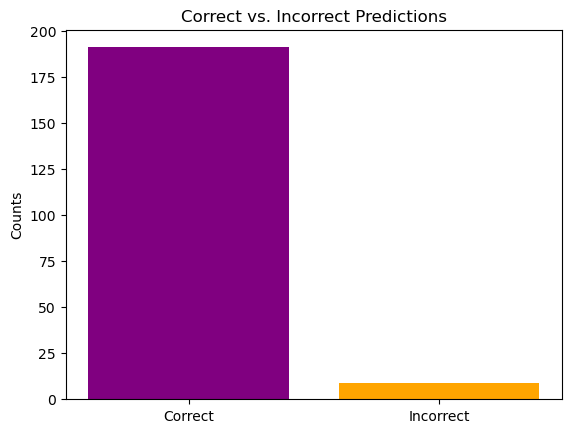

In [17]:
correct = (y_test == y_pred)

counts = correct.value_counts()
print(counts)
labels = ['Correct', 'Incorrect']
heights = [counts.get(True,0),counts.get(False , 0)]

plt.bar(labels, heights , color = ['purple','orange'])
plt.title('Correct vs. Incorrect Predictions')
plt.ylabel('Counts')
plt.show()

### Exporting ML results , for Power BI model

In [18]:
results_df = X_test.copy()
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred

results_df.to_csv('Random Forest Prediction Results.csv', index = False)

### Results with a Logistic Regression classifier 

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [22]:
# Evaluate the model
y_pred = lr.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 68.00%


In [23]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[122  15]
 [ 49  14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.89      0.79       137
           1       0.48      0.22      0.30        63

    accuracy                           0.68       200
   macro avg       0.60      0.56      0.55       200
weighted avg       0.64      0.68      0.64       200



Text(0.5, 1.0, "Logistic Regression Classifiers' Confusion Matrix")

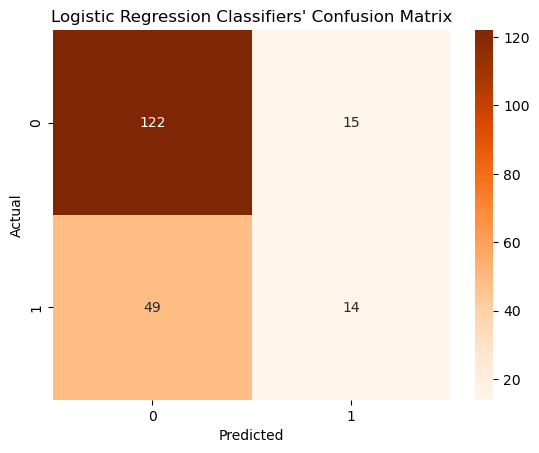

In [24]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot= True,
           fmt = 'd',cmap = 'Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Logistic Regression Classifiers' Confusion Matrix")